In [1]:
pip install jupyter pandas numpy matplotlib scikit-learn xgboost shap pandas-gbq google-cloud-bigquery db-dtypes

  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyasn1-0.6.4-py3-none-any.whl.metadata (8.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 3.6 MB/s  0:00:03a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 5.7 MB/s  0:00:00m 5.8 MB/s eta 0:00:01
Using cached pyasn1_modules-0.4.2-py3-none-any.whl (181 kB)
Using cached pyasn1-0.6.4-py3-none-any.whl (84 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 4.2 MB/s  0:00:09a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 3.5 MB/s  0:00:00m 4.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25/25 [pandas-gbq]0m 24/25 [pandas-gbq]]]-modules]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install -U pandas-gbq google-cloud-bigquery db-dtypes pyarrow

  Using cached pyarrow-25.0.1-cp314-cp314-macosx_12_0_arm64.whl.metadata (3.0 kB)
Using cached pyarrow-25.0.1-cp314-cp314-macosx_12_0_arm64.whl (35.9 MB)
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 25.0.0
    Uninstalling pyarrow-25.0.0:
      Successfully uninstalled pyarrow-25.0.0

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_gbq

In [2]:
query = """
SELECT *
FROM `amplified-alpha-463610-c8.ecommerce_ml.session_features`
"""

df = pandas_gbq.read_gbq(
    query,
    project_id="amplified-alpha-463610-c8",
    dialect="standard"
)

df.head()

Please visit this URL to authorize this application: https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=262006177488-3425ks60hkk80fssi9vpohv88g6q1iqd.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8080%2F&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fbigquery&state=215asBcTwThX6nG74smTUFZjCJOH89&code_challenge=rbhvoLXsjlfLw7mNUhlNB6k_o6EIPTaGRwpFhG7rUjM&code_challenge_method=S256&prompt=consent&access_type=offline
Downloading: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████|


,user_pseudo_id,session_id,session_date,total_events_5min,page_views_5min,product_views_5min,product_clicks_5min,add_to_cart_5min,begin_checkout_5min,search_events_5min,is_new_user,device_category,operating_system,mobile_brand,mobile_model,traffic_source,traffic_medium,target
0,56162479.7328415035,3120510756,2020-11-21,13,4,2,0,0,0,0,0,mobile,Android,Samsung,<Other>,(data deleted),(data deleted),0
1,38649160.6784990719,5087740138,2020-11-30,2,0,0,0,0,0,0,0,mobile,Android,Samsung,<Other>,(data deleted),(data deleted),0
2,34497430.3741988669,6112241130,2020-12-18,22,9,1,1,0,0,0,0,mobile,Web,Samsung,<Other>,<Other>,(data deleted),0
3,54536524.4339644387,2096827012,2021-01-28,5,2,0,0,0,0,0,0,mobile,Web,<Other>,<Other>,(data deleted),(data deleted),0
4,16851116.6419517132,7459325817,2020-12-07,11,3,3,0,0,0,0,0,mobile,Web,<Other>,<Other>,(data deleted),(data deleted),0


In [3]:
df.shape

(359603, 18)

In [4]:
df["target"].value_counts()

target
0    355281
1      4322
Name: count, dtype: Int64

In [5]:
df["target"].mean() * 100

np.float64(1.2018809631732772)

In [6]:
conversion_rate = df["target"].mean() * 100
print(round(conversion_rate, 3))

1.202


In [7]:
print(f"Conversion Rate: {conversion_rate:.3f}%")

Conversion Rate: 1.202%


In [8]:
df.shape

(359603, 18)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 359603 entries, 0 to 359602
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   user_pseudo_id       359603 non-null  str   
 1   session_id           359603 non-null  Int64 
 2   session_date         359603 non-null  dbdate
 3   total_events_5min    359603 non-null  Int64 
 4   page_views_5min      359603 non-null  Int64 
 5   product_views_5min   359603 non-null  Int64 
 6   product_clicks_5min  359603 non-null  Int64 
 7   add_to_cart_5min     359603 non-null  Int64 
 8   begin_checkout_5min  359603 non-null  Int64 
 9   search_events_5min   359603 non-null  Int64 
 10  is_new_user          359603 non-null  Int64 
 11  device_category      359603 non-null  str   
 12  operating_system     359603 non-null  str   
 13  mobile_brand         359603 non-null  str   
 14  mobile_model         359603 non-null  str   
 15  traffic_source       359603 non-null  str   


In [10]:
df.isnull().sum().sort_values(ascending=False)

user_pseudo_id         0
session_id             0
traffic_medium         0
traffic_source         0
mobile_model           0
mobile_brand           0
operating_system       0
device_category        0
is_new_user            0
search_events_5min     0
begin_checkout_5min    0
add_to_cart_5min       0
product_clicks_5min    0
product_views_5min     0
page_views_5min        0
total_events_5min      0
session_date           0
target                 0
dtype: int64

In [11]:
df.duplicated(
    subset=["user_pseudo_id", "session_id"]
).sum()

np.int64(0)

In [12]:
df.describe()

,session_id,total_events_5min,page_views_5min,product_views_5min,product_clicks_5min,add_to_cart_5min,begin_checkout_5min,search_events_5min,is_new_user,target
count,359603.0,359603.0,359603.0,359603.0,359603.0,359603.0,359603.0,359603.0,359603.0,359603.0
mean,4993242842.374766,8.022867,2.532076,0.4936,0.045364,0.074262,0.024349,0.047914,0.715417,0.012019
std,2886845845.615736,8.392558,2.967997,1.493433,0.301243,0.569231,0.291474,0.300797,0.451216,0.10897
min,1205.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,2496207743.0,4.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,4988720956.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
75%,7491709861.0,8.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
max,9999997129.0,138.0,114.0,51.0,16.0,29.0,15.0,16.0,1.0,1.0


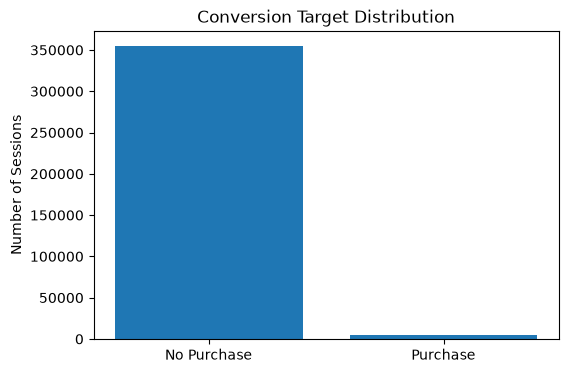

In [13]:
target_counts = df["target"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["No Purchase", "Purchase"],
    target_counts.values
)

plt.title("Conversion Target Distribution")
plt.ylabel("Number of Sessions")
plt.show()

In [14]:
cart_analysis = (
    df.assign(
        cart_status=np.where(
            df["add_to_cart_5min"] > 0,
            "Added to Cart",
            "No Cart"
        )
    )
    .groupby("cart_status")["target"]
    .agg(["count", "sum", "mean"])
)

cart_analysis["conversion_rate_percent"] = (
    cart_analysis["mean"] * 100
)

cart_analysis

,count,sum,mean,conversion_rate_percent
cart_status,,,,
Added to Cart,11144,1874,0.168162,16.816224
No Cart,348459,2448,0.007025,0.702522


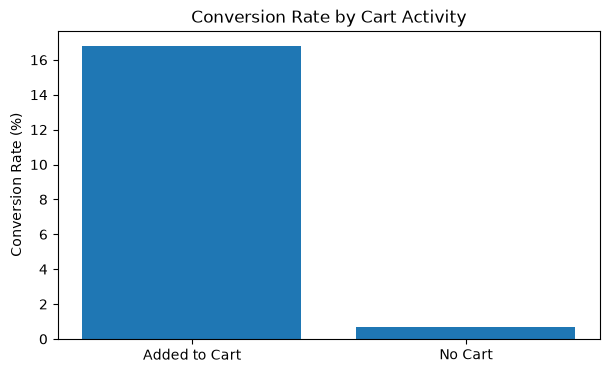

In [15]:
cart_plot = cart_analysis["conversion_rate_percent"]

plt.figure(figsize=(7, 4))
plt.bar(cart_plot.index, cart_plot.values)

plt.title("Conversion Rate by Cart Activity")
plt.ylabel("Conversion Rate (%)")
plt.show()

In [16]:
checkout_analysis = (
    df.assign(
        checkout_status=np.where(
            df["begin_checkout_5min"] > 0,
            "Started Checkout",
            "No Checkout"
        )
    )
    .groupby("checkout_status")["target"]
    .agg(["count", "sum", "mean"])
)

checkout_analysis["conversion_rate_percent"] = (
    checkout_analysis["mean"] * 100
)

checkout_analysis

,count,sum,mean,conversion_rate_percent
checkout_status,,,,
No Checkout,355936,3393,0.009533,0.953261
Started Checkout,3667,929,0.253341,25.334061


In [17]:
checkout_analysis = (
    df.assign(
        checkout_status=np.where(
            df["begin_checkout_5min"] > 0,
            "Started Checkout",
            "No Checkout"
        )
    )
    .groupby("checkout_status")["target"]
    .agg(["count", "sum", "mean"])
)

checkout_analysis["conversion_rate_percent"] = (
    checkout_analysis["mean"] * 100
)

checkout_analysis

,count,sum,mean,conversion_rate_percent
checkout_status,,,,
No Checkout,355936,3393,0.009533,0.953261
Started Checkout,3667,929,0.253341,25.334061


In [18]:
user_analysis = (
    df.assign(
        user_type=np.where(
            df["is_new_user"] == 1,
            "New User",
            "Returning User"
        )
    )
    .groupby("user_type")["target"]
    .agg(["count", "sum", "mean"])
)

user_analysis["conversion_rate_percent"] = (
    user_analysis["mean"] * 100
)

user_analysis

,count,sum,mean,conversion_rate_percent
user_type,,,,
New User,257266,1602,0.006227,0.622702
Returning User,102337,2720,0.026579,2.657885


In [19]:
device_analysis = (
    df.groupby("device_category")["target"]
    .agg(["count", "sum", "mean"])
)

device_analysis["conversion_rate_percent"] = (
    device_analysis["mean"] * 100
)

device_analysis.sort_values(
    "conversion_rate_percent",
    ascending=False
)

,count,sum,mean,conversion_rate_percent
device_category,,,,
mobile,142966,1776,0.012423,1.242253
desktop,208646,2453,0.011757,1.175676
tablet,7991,93,0.011638,1.163809


In [20]:
df["product_view_group"] = pd.cut(
    df["product_views_5min"],
    bins=[-1, 0, 1, 2, 4, 9, float("inf")],
    labels=["0", "1", "2", "3-4", "5-9", "10+"]
)

product_analysis = (
    df.groupby(
        "product_view_group",
        observed=True
    )["target"]
    .agg(["count", "sum", "mean"])
)

product_analysis["conversion_rate_percent"] = (
    product_analysis["mean"] * 100
)

product_analysis

,count,sum,mean,conversion_rate_percent
product_view_group,,,,
0,290945,443,0.001523,0.152262
1,32067,518,0.016154,1.615368
2,14280,572,0.040056,4.005602
3-4,12243,983,0.080291,8.029078
5-9,8225,1336,0.162432,16.243161
10+,1843,470,0.255019,25.501899


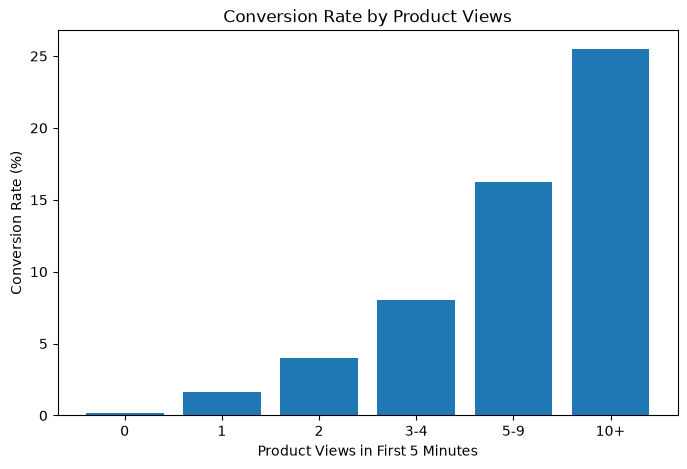

In [21]:
plt.figure(figsize=(8, 5))

plt.bar(
    product_analysis.index.astype(str),
    product_analysis["conversion_rate_percent"]
)

plt.title("Conversion Rate by Product Views")
plt.xlabel("Product Views in First 5 Minutes")
plt.ylabel("Conversion Rate (%)")

plt.show()